In [1]:
#Librerias y rutas
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from pathlib import Path

ROOT = Path(".")
DATA = ROOT / "Data"

In [2]:
clientes = pd.read_csv(
    DATA / "2026-07-20_3_bank_dataset_transformed.csv"
)

clientes.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,...,age_group,housing_score,loan_score,vinculacion,productos_detalle,education_rank,education_label,job_profile,week_of_month,campaign_group
0,1,59.0,admin.,married,secondary,no,2343,yes,no,unknown,...,Mediana edad (55-64),1,0,2,Hipoteca + Depósito,2.0,Secondary,White Collar,1,0-3
1,2,56.0,admin.,married,secondary,no,45,no,no,unknown,...,Mediana edad (55-64),0,0,1,Depósito,2.0,Secondary,White Collar,1,0-3
2,3,41.0,technician,married,secondary,no,1270,yes,no,unknown,...,Adultos iniciales(35-44),1,0,2,Hipoteca + Depósito,2.0,Secondary,White Collar,1,0-3
3,4,55.0,services,married,secondary,no,2476,yes,no,unknown,...,Mediana edad (55-64),1,0,2,Hipoteca + Depósito,2.0,Secondary,Blue Collar,1,0-3
4,5,54.0,admin.,married,tertiary,no,184,no,no,unknown,...,Adultos maduros (45-54),0,0,1,Depósito,3.0,Tertiary,White Collar,1,0-3


In [3]:
df_raw = pd.read_excel(
    DATA / "2026-07-20_INE_2026_2036_poblacion.xlsx",
    sheet_name=0,
    header=6
)

In [4]:
df_poblacion = df_raw.iloc[:103].copy()

In [5]:
primer_col = df_poblacion.columns[0]

df_poblacion = df_poblacion.rename(
    columns={primer_col: "age"}
)

In [6]:
# Eliminar las filas "Total" y "Todas las edades"
df_poblacion = df_poblacion[
    df_poblacion["age"].astype(str).str.contains(r"\d")
].copy()

In [7]:
#Extraer el número de edad
df_poblacion["age"] = (
    df_poblacion["age"]
        .astype(str)
        .str.extract(r"(\d+)", expand=False)
        .astype(int)
)

In [ ]:
df_poblacion = (
    df_poblacion
    .reset_index(drop=True)
)

In [8]:
saldo_raw = pd.read_excel(
    DATA / "2026-07-20_INE_2026_2075_saldo_vegetativo.xlsx",
    sheet_name=0,
    header=6
)

In [9]:
migracion_raw = pd.read_excel(
    DATA / "2026-07-20_INE_2026-2075_migracion_neta.xlsx",
    sheet_name=0,
    header=6
)

In [10]:
clientes_enriquecido = clientes.merge(
    df_poblacion,
    on="age",
    how="left",
    validate="many_to_one"
)

In [11]:
clientes_enriquecido.to_csv(
    DATA / "clientes_enriquecido_poblacion.csv",
    index=False
)

In [13]:
# ==========================================
# AUDITORÍA DEL MERGE
# ==========================================

print(f"Filas: {clientes_enriquecido.shape[0]}")
print(f"Columnas: {clientes_enriquecido.shape[1]}")

display(clientes_enriquecido.head())

Filas: 11150
Columnas: 81


,id,age,job,marital,education,default,balance,housing,loan,contact,...,2035,2034,2033,2032,2031,2030,2029,2028,2027,2026
0,1,59.0,admin.,married,secondary,no,2343,yes,no,unknown,...,832515.661711,823224.514406,800452.479702,792766.161789,777449.325559,763013.056517,751374.270664,740894.151756,742537.194680,722151.0
1,2,56.0,admin.,married,secondary,no,45,no,no,unknown,...,836314.896710,840882.693787,849420.217372,838064.450477,828109.883236,804079.483975,795860.358874,779476.164502,764544.919266,752068.0
2,3,41.0,technician,married,secondary,no,1270,yes,no,unknown,...,667988.742154,672910.512633,661257.178657,658140.139921,655733.067695,654191.829997,648897.254939,650004.143846,655896.188792,666610.0
3,4,55.0,services,married,secondary,no,2476,yes,no,unknown,...,811440.219048,837433.040845,841832.348599,850152.950691,838461.374166,828221.461427,803712.269505,795340.045243,778652.397132,763736.0
4,5,54.0,admin.,married,tertiary,no,184,no,no,unknown,...,799032.116206,812000.859440,837913.891399,842098.435068,850156.642239,838096.623574,827566.680208,802588.692362,794143.690789,777262.0


In [14]:
missing = (
    clientes_enriquecido
    .isna()
    .sum()
    .sort_values(ascending=False)
)

display(missing[missing > 0])

education_rank    496
dtype: int64

In [19]:
display(clientes_enriquecido.head())

,id,age,job,marital,education,default,balance,housing,loan,contact,...,2035,2034,2033,2032,2031,2030,2029,2028,2027,2026
0,1,59.0,admin.,married,secondary,no,2343,yes,no,unknown,...,832515.661711,823224.514406,800452.479702,792766.161789,777449.325559,763013.056517,751374.270664,740894.151756,742537.194680,722151.0
1,2,56.0,admin.,married,secondary,no,45,no,no,unknown,...,836314.896710,840882.693787,849420.217372,838064.450477,828109.883236,804079.483975,795860.358874,779476.164502,764544.919266,752068.0
2,3,41.0,technician,married,secondary,no,1270,yes,no,unknown,...,667988.742154,672910.512633,661257.178657,658140.139921,655733.067695,654191.829997,648897.254939,650004.143846,655896.188792,666610.0
3,4,55.0,services,married,secondary,no,2476,yes,no,unknown,...,811440.219048,837433.040845,841832.348599,850152.950691,838461.374166,828221.461427,803712.269505,795340.045243,778652.397132,763736.0
4,5,54.0,admin.,married,tertiary,no,184,no,no,unknown,...,799032.116206,812000.859440,837913.891399,842098.435068,850156.642239,838096.623574,827566.680208,802588.692362,794143.690789,777262.0


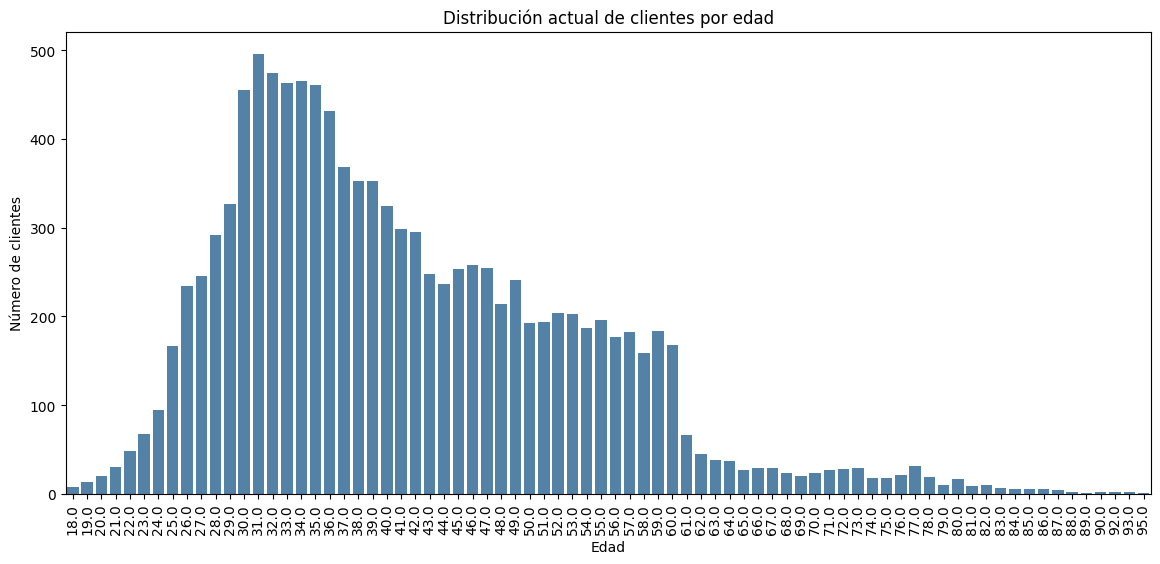

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

clientes_por_edad = (
    clientes_enriquecido
    .groupby("age")
    .size()
    .reset_index(name="clientes")
)

plt.figure(figsize=(14,6))

sns.barplot(
    data=clientes_por_edad,
    x="age",
    y="clientes",
    color="steelblue"
)

plt.title("Distribución actual de clientes por edad")
plt.xlabel("Edad")
plt.ylabel("Número de clientes")

plt.xticks(rotation=90)

plt.show()

In [21]:
proyecciones = (
    clientes_enriquecido
    .groupby("age")[
        ["2026","2027","2028","2029","2030",
         "2031","2032","2033","2034","2035"]
    ]
    .first()
)

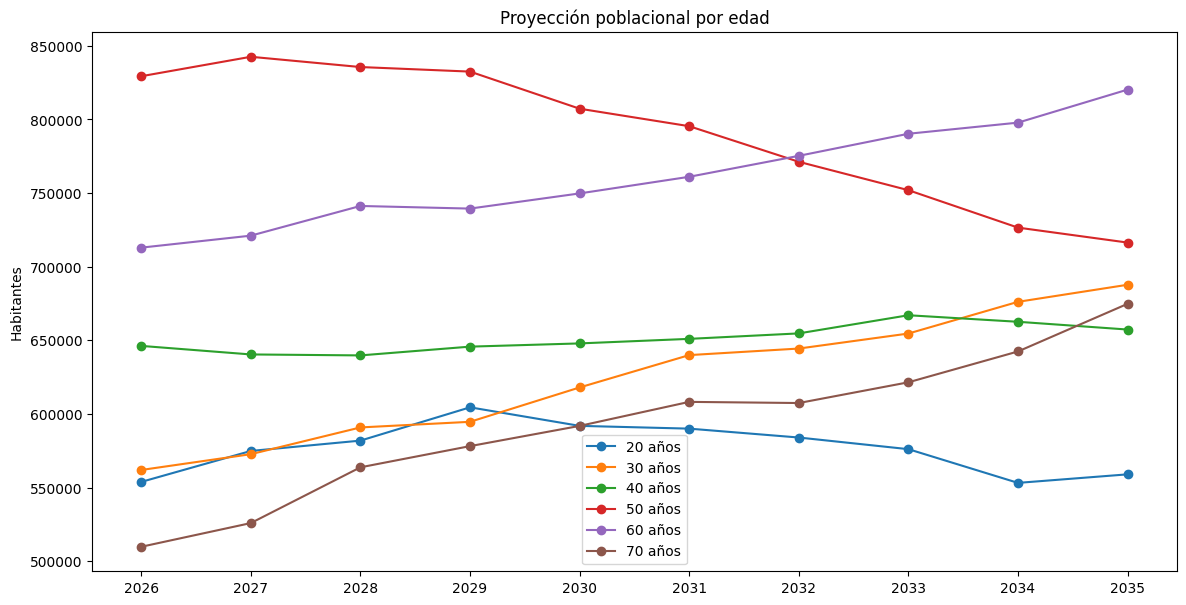

In [22]:
plt.figure(figsize=(14,7))

for edad in [20,30,40,50,60,70]:
    if edad in proyecciones.index:
        plt.plot(
            proyecciones.columns,
            proyecciones.loc[edad],
            marker="o",
            label=f"{edad} años"
        )

plt.legend()

plt.title("Proyección poblacional por edad")

plt.ylabel("Habitantes")

plt.show()


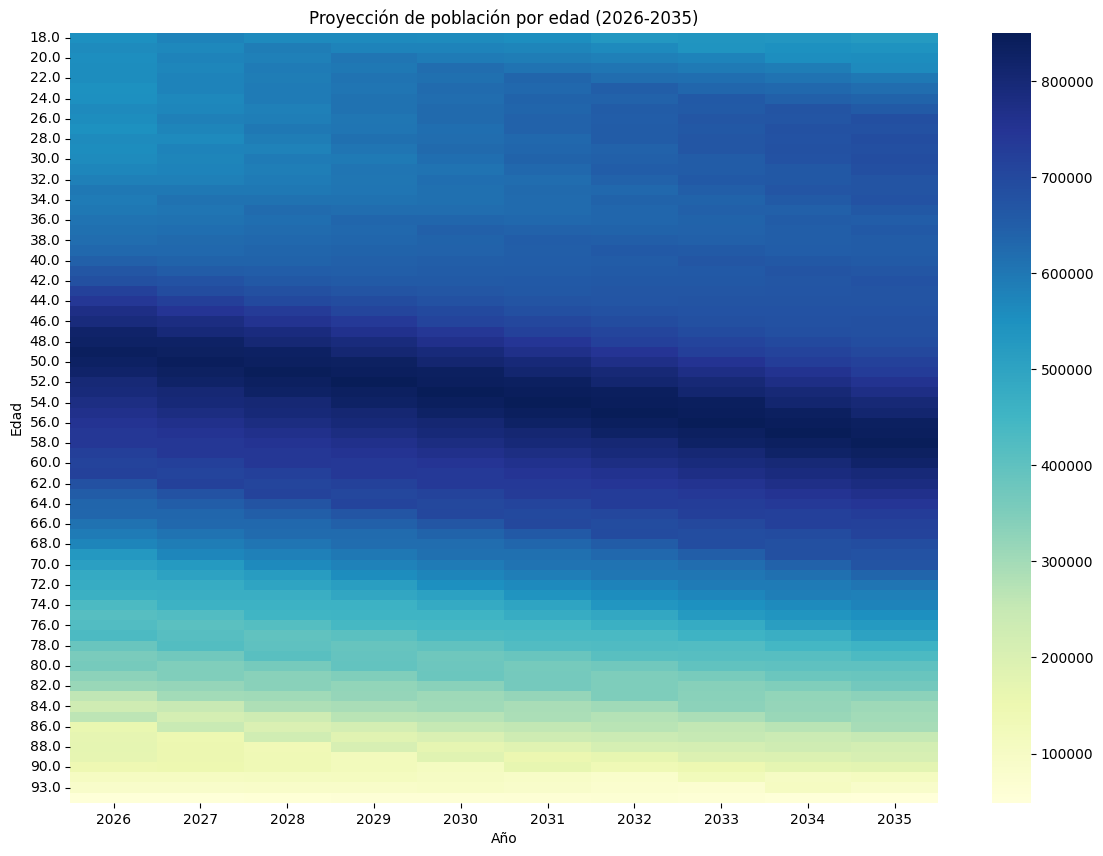

In [23]:
plt.figure(figsize=(14,10))

sns.heatmap(
    proyecciones,
    cmap="YlGnBu"
)

plt.title("Proyección de población por edad (2026-2035)")
plt.xlabel("Año")
plt.ylabel("Edad")

plt.show()

In [24]:
comparacion = clientes_por_edad.merge(
    proyecciones[["2035"]],
    left_on="age",
    right_index=True
)

In [25]:
comparacion["clientes_norm"] = (
    comparacion["clientes"] /
    comparacion["clientes"].max()
)

comparacion["poblacion_norm"] = (
    comparacion["2035"] /
    comparacion["2035"].max()
)

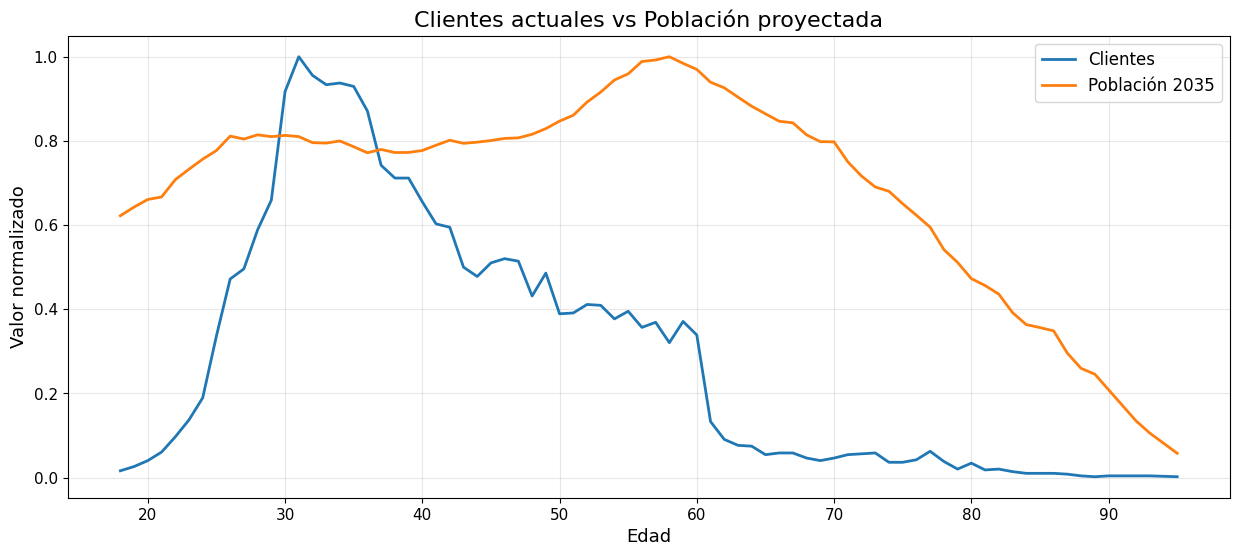

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

plt.plot(
    comparacion["age"],
    comparacion["clientes_norm"],
    label="Clientes",
    linewidth=2
)

plt.plot(
    comparacion["age"],
    comparacion["poblacion_norm"],
    label="Población 2035",
    linewidth=2
)

plt.title("Clientes actuales vs Población proyectada", fontsize=16)
plt.xlabel("Edad", fontsize=13)
plt.ylabel("Valor normalizado", fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)

plt.show()

Interpretación: La gráfica compara la distribución de los clientes actuales con la distribución proyectada de la población para 2035, ambas normalizadas para facilitar la comparación de sus formas. Se observa que ambas curvas presentan una tendencia similar, con una mayor concentración en las edades adultas y una disminución progresiva en los grupos de mayor edad. Sin embargo, existen diferencias en algunos rangos de edad, donde la proporción de clientes es superior o inferior a la esperada según la estructura demográfica proyectada. Estas discrepancias indican que determinados segmentos de edad están sobre- o infrarepresentados en la cartera de clientes respecto a la población futura, lo que puede señalar oportunidades para adaptar las estrategias de captación o fidelización hacia aquellos grupos con mayor potencial de crecimiento.

In [29]:
clientes_migracion = clientes.merge(
    df_migracion,
    on="age",
    how="left",
    validate="many_to_one"
)

NameError: name 'df_migracion' is not defined